# init
---

In [1]:
#### mv packages ####
import modules.data as d
import modules.model as m
import modules.pooling as p
import modules.train as t
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:6'])#['cuda:1', 'cuda:0'])
# device, generator = u.Devices().set_device('cpu')

#### data ####
brca = d.Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=dataset_dir/'tcga',
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    
    # counts
    apply_DESeq_norm=False, 
    log_transform=False,
    scale_method=None,

    # etc
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
)
_dataset = d.GraphDataset(brca)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:1

# #### Preprocessor() ####
# log0_method              log1p                    str
# class_weights            (6,)                     Tensor (cuda:1)
# edge_index               (2, 32798)               Tensor (cuda:1)
# edge_attr                (32798, 16)              Tensor (cuda:1)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# mask_list                305                      list
# mask                     (4383, 305)              Tensor (cuda:1)
# x                        (562, 4383, 1)           Tensor (cuda:1)
# y                        (562,)                   Tensor (cuda:1)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int


In [2]:
#### convenience variables ####
_embedding_size = 16

# from mask (init)
_mask = brca.mask
_num_nodes, _num_sets = _mask.shape

# from batch (forward)
_batch_size = int(_batch.x.shape[0]/_num_nodes)
_num_node_features = _batch.x.shape[1] # or brca.num_node_features
_x = _batch.x.view(_batch.batch_size, int(_batch.x.shape[0]/_batch.batch_size), -1)

# pytorch GLMs
---

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.init as init
import numpy as np

from torch import Tensor
from torch_geometric.data import Batch
from typing import Literal, Optional

In [4]:
def reshape_x(to:Literal['b,n,f','b*n,f','b,n*f'], x:Optional[Tensor]=None, batch:Optional[Batch]=None, batch_size:Optional[int]=None, num_nodes:Optional[int]=None, num_node_features:Optional[int]=None):
    '''
    detects x of size (b,n,f), (b*n,f), or (b,n*f) and returns desired view
    '''
    # read batch
    if batch is not None:
        x = batch.x if x is None else x
        batch_size = batch.batch_size
        num_node_features = batch.num_node_features
        
    # ensure supported dim
    
    assert x.dim() in (2,3), f'unsupported x.dim(): {x.dim()}'

    # b,n,f all known
    if (batch_size is not None) and (num_nodes is not None) and (num_node_features is not None):
        pass # do nothing
    elif x.dim() == 3:
        batch_size, num_nodes, num_node_features = x.shape

    # one unknown (dim = 2)
    else:
        # find num_nodes
        if (batch_size is not None) and (num_node_features is not None):
            if x.shape[-1] == num_node_features: # b*n,f case
                num_nodes = int(x.shape[0]//batch_size)
            else: # b,n*f case
                num_nodes = int(x.shape[-1]//num_node_features)

        # find batch_size
        elif (num_nodes is not None) and (num_node_features is not None):
            if x.shape[-1] == num_node_features: # b*n,f case
                batch_size = int(x.shape[0]//num_nodes)
            else: # b,n*f case
                batch_size = x.shape[0]

        # find num_node_features
        elif (batch_size is not None) and (num_nodes is not None):
            if x.shape[0] == batch_size: # b,n*f case
                num_node_features = int(x.shape[-1]//num_nodes)
            else: # b*n,f case
                num_nodes = x.shape[-1]

        # not enough information
        assert sum(p is not None for p in [batch_size, num_nodes, num_node_features]) >= 2, 'two of [batch_size, num_nodes, num_node_features] must be provided'

    # reshape
    if to == 'b,n,f':
        x = x.reshape(batch_size, num_nodes, num_node_features)
    elif to == 'b*n,f':
        x = x.reshape(batch_size * num_nodes, num_node_features)
    else: # 'b,n*f
        x = x.reshape(batch_size, num_nodes * num_node_features)

    return x

In [5]:
reshape_x('b,n,f', batch=_batch).shape

torch.Size([64, 4383, 1])

In [26]:
class ZINBGenLinModel(nn.Module):
    def __init__(self, in_features:int, init_dispersion:float=1.0, eps:float=1e-6, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.in_features = in_features
        self.eps = eps

        # negative binomial (NB) GLM -> mu (prob not pi = NB)
        self.lin_mu = nn.Linear(self.in_features, 1)
        init.xavier_uniform_(self.lin_mu.weight)
        # init.constant_(self.lin_mu.bias, 9) # softplus(9) ~ 5000 (mean)

        # dispersion param.
        self.log_theta = nn.Parameter(torch.tensor([init_dispersion]).log())

        # zero-inflation (ZI) GLM -> pi (prob. 'dropout/structural' 0)
        self.lin_pi = nn.Linear(self.in_features, 1)
        init.xavier_uniform_(self.lin_pi.weight)
        init.constant_(self.lin_pi.bias, -12.0) # sigmoid(-2) ~ 0.1

    def forward(self, x:Optional[Tensor]=None, batch:Optional[Batch]=None, return_dict:bool=True, *args, **kwargs):
        # handle batch if provided
        x = reshape_x(to='b,n,f', x=x, batch=batch) # x in (b,n,f)

        # log_mu -> mu in (b,n,1)
        mu = F.softplus(self.lin_mu(x)) + self.eps 

        # log_theta -> theta in (1,)
        theta = F.softplus(self.log_theta) + self.eps 

        # logit_pi -> pi [0,1] in (b,n,1)
        pi = torch.sigmoid(self.lin_pi(x))

        # clamp for stability
        mu = torch.clamp(mu, min=self.eps)
        theta = torch.clamp(theta, min=self.eps)
        pi = torch.clamp(pi, min=self.eps, max=1.0-self.eps) # max = (1-(1-eps)) = eps

        # match theta to mu for loss fxn
        theta = theta.expand_as(mu)

        # predict/reconstruct x
        x_recon = (1 - pi) * mu

        if return_dict:
            return {'x_recon':x_recon, 'mu':mu, 'theta':theta, 'pi':pi}
        else:
            return x_recon, mu, theta, pi
        

In [27]:
class ZINBLoss(nn.Module):
    def __init__(self, eps:float=1e-6, ridge_lambda:float=0.0, approx:bool=False):
        '''
        eps: small value to prevent division by zero / log(0)
        ridge_lambda: optional L2 penalty on mean (for ridge regularization)
        '''
        super().__init__()
        self.eps = eps
        self.ridge_lambda = ridge_lambda
        self.approx = approx

    def forward(self, x, mu, theta, pi):
        '''
        x:  observed counts
        mu: predicted mean counts
        theta: predicted dispersion
        pi: predicted zero-inflation logits (probability of extra zero)
        assumes inputs are positive / constrained appropriately
        '''
    
        # clamp non-zero, positive for log/lgamma stability
        eps = self.eps
        mu = torch.clamp(mu, min=eps)
        theta = torch.clamp(theta, min=eps)
        pi = torch.clamp(pi, min=eps, max=1.0-eps) # max = (1-(1-eps)) = eps

        # common terms
        log_theta_mu = torch.log(theta + mu + eps) # NB denom
        log_theta = torch.log(theta + eps)
        log_mu = torch.log(mu + eps)

        # log prob of NB(x)
        log_nb = (
            theta * (log_theta - log_theta_mu) +
            x * (log_mu - log_theta_mu)
        )

        # gamma term (slow, unstable)
        if not self.approx:
            log_nb += (
                torch.lgamma(x + theta + eps) -
                torch.lgamma(theta + eps) -
                torch.lgamma(x + 1)
            )

        # log prob NB(x=0)
        log_nb_zero = (
            theta * (log_theta - log_theta_mu)
        )

        # piecewise negative log-likelihood
        zero_case = torch.logsumexp(torch.stack([
            torch.log(pi),
            torch.log(1.0 - pi) + log_nb_zero
        ], dim=0), dim=0)

        count_case = torch.log(1.0 - pi) + log_nb
        zinb_loss = torch.where(x < eps, -zero_case, -count_case)

        # L2 (ridge) regularization (optional)
        if self.ridge_lambda > 0:
            zinb_loss += self.ridge_lambda * mu.pow(2)
            zinb_loss += self.ridge_lambda * (torch.logit(pi)).pow(2)

        return zinb_loss.mean()  # average loss over batch
        



---

In [28]:
from modules.train import Loader, Trainer
from torchmetrics.functional import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

class ZINBTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract x
        x = reshape_x(to='b,n,f',batch=batch)

        # forward pass
        out = self.model(x, batch=batch)

        # get ZINB loss params
        mu = out.get('mu')
        theta = out.get('theta')
        pi = out.get('pi')

        # compute ZINB loss
        loss = self.loss_fn(x, mu, theta, pi)

        return loss, out
    
    def _compute_metrics(self, batch_log:dict): # change in child
        # init
        metrics = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        x = torch.cat([
            batch['x'].view(
                batch['batch_size'],
                int(batch['x'].shape[0]/batch['batch_size']),
                -1
            )
            for batch in batch_log['batch']
        ]).squeeze(-1)
        x_recon = torch.cat([batch['x_recon'] for batch in batch_log['out']]).squeeze(-1)
        mu = torch.cat([batch['mu'] for batch in batch_log['out']]).squeeze(-1)
        theta = torch.cat([batch['theta'] for batch in batch_log['out']]).squeeze(-1)
        pi = torch.cat([batch['pi'] for batch in batch_log['out']]).squeeze(-1)

        # scale outputs to log2        
        log2_x = torch.log2(x + 1e-6)
        log2_x_recon = torch.log2(x_recon + 1e-6)
        log2fc = log2_x_recon - log2_x
        mse = mean_squared_error(log2_x_recon, log2_x)

        # compute log2 metrics
        metrics['nll_zinb'] = ZINBLoss()(x, mu, theta, pi).item()
        metrics['mean'] = torch.mean(log2fc).item()
        metrics['std'] = torch.std(log2fc).item()
        metrics['mae'] = mean_absolute_error(log2_x_recon, log2_x).item()
        metrics['mse'] = mse.item()
        metrics['rmse'] = torch.sqrt(mse).item()
        metrics['r2'] = r2_score(log2_x_recon, log2_x).item()

        # convert values to numpy
        values = {
            'x': x.cpu().numpy(),
            'x_recon': x_recon.cpu().numpy(),
            'mu': mu.cpu().numpy(),
            'theta': theta.cpu().numpy(),
            'pi': pi.cpu().numpy(),
        }

        return metrics, values

In [38]:
zinb_glm = ZINBGenLinModel(brca.num_node_features, eps=1e-6)

loader = Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

trainer = ZINBTrainer(
    model=zinb_glm,
    loader=loader,
    num_epochs=100,
    loss_fn=ZINBLoss(ridge_lambda=1e-3),
    optimizer_kwargs={'lr':1e-3},
    verbose=True,
    report_metrics=['loss','mae', 'rmse']
    # clip_gradients=True
)

display(trainer.test_metrics)

for i in ['mu','theta','pi']:
    for k,v in {'mean':np.mean, 'std':np.std, 'min':np.min, 'max':np.max}.items():
        print(f'({i}) {k}: {v(trainer.test_values[i])}')

100%|██████████| 100/100 [00:06<00:00, 16.30it/s, Epoch 99      Train: loss=83.8621    mae=25.4417    rmse=25.8894        Val: loss=82.8437    mae=25.3691    rmse=25.8403]   

Test	 loss=87.3881    mae=25.4698    rmse=25.9078



{'loss': 87.38809967041016,
 'nll_zinb': 65.14082336425781,
 'mean': -25.256668090820312,
 'std': 5.771728992462158,
 'mae': 25.469768524169922,
 'mse': 671.2120361328125,
 'rmse': 25.907760620117188,
 'r2': -739.7202758789062}

(mu) mean: 36.5152702331543
(mu) std: 143.98204040527344
(mu) min: 1.1578404903411865
(mu) max: 14207.0029296875
(theta) mean: 0.4141184687614441
(theta) std: 8.940696716308594e-08
(theta) min: 0.41411837935447693
(theta) max: 0.41411837935447693
(pi) mean: 0.963009238243103
(pi) std: 0.1835746020078659
(pi) min: 4.013169018435292e-06
(pi) max: 0.9999989867210388


In [ ]:
# these params get the best results
# (mu) mean: 5446.46240234375
# (mu) std: 20550.455078125
# (mu) min: 3.998577833175659
# (mu) max: 1427078.25
# (theta) mean: 0.7031903862953186
# (theta) std: 2.384185791015625e-07
# (theta) min: 0.7031906247138977
# (theta) max: 0.7031906247138977
# (pi) mean: 0.0009352935594506562
# (pi) std: 0.009446348994970322
# (pi) min: 9.999999974752427e-07
# (pi) max: 0.12131576985120773

# results
# {'loss': 45206.73828125,
#  'nll_zinb': 8.205657005310059,
#  'mean': 0.3611769378185272,
#  'std': 1.573677897453308,
#  'mae': 0.3611769378185272,
#  'mse': 2.6069042682647705,
#  'rmse': 1.6145910024642944,
#  'r2': 0.8995018005371094}



In [ ]:
'''
{'loss': 33.462066650390625,
 'nll_zinb': 3588.74951171875,
 'mean': -5.451621055603027,
 'std': 1.9840526580810547,
 'mae': 5.666528224945068,
 'rmse': 5.801433086395264,
 'r2': -40.163761138916016}

{'loss': 5.0372314453125,
 'nll_zinb': 6123.7841796875,
 'mean': 0.10849224776029587,
 'std': 1.6079609394073486,
 'mae': 0.17866577208042145,
 'mse': 2.597301959991455,
 'rmse': 1.61161470413208,
 'r2': 0.9521775841712952}
 
'''

"\n{'loss': 33.462066650390625,\n 'nll_zinb': 3588.74951171875,\n 'mean': -5.451621055603027,\n 'std': 1.9840526580810547,\n 'mae': 5.666528224945068,\n 'rmse': 5.801433086395264,\n 'r2': -40.163761138916016}\n\n{'loss': 5.0372314453125,\n 'nll_zinb': 6123.7841796875,\n 'mean': 0.10849224776029587,\n 'std': 1.6079609394073486,\n 'mae': 0.17866577208042145,\n 'mse': 2.597301959991455,\n 'rmse': 1.61161470413208,\n 'r2': 0.9521775841712952}\n \n"

---

In [ ]:
import numpy as np
import scipy.cluster.hierarchy as sch

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
x_in = trainer.test_values['x']
x_out = trainer.test_values['x_recon']
np.percentile(x_in, [0, 25, 50, 75, 100])

array([0.000000e+00, 3.950000e+02, 1.515500e+03, 4.221000e+03,
       1.936562e+06])

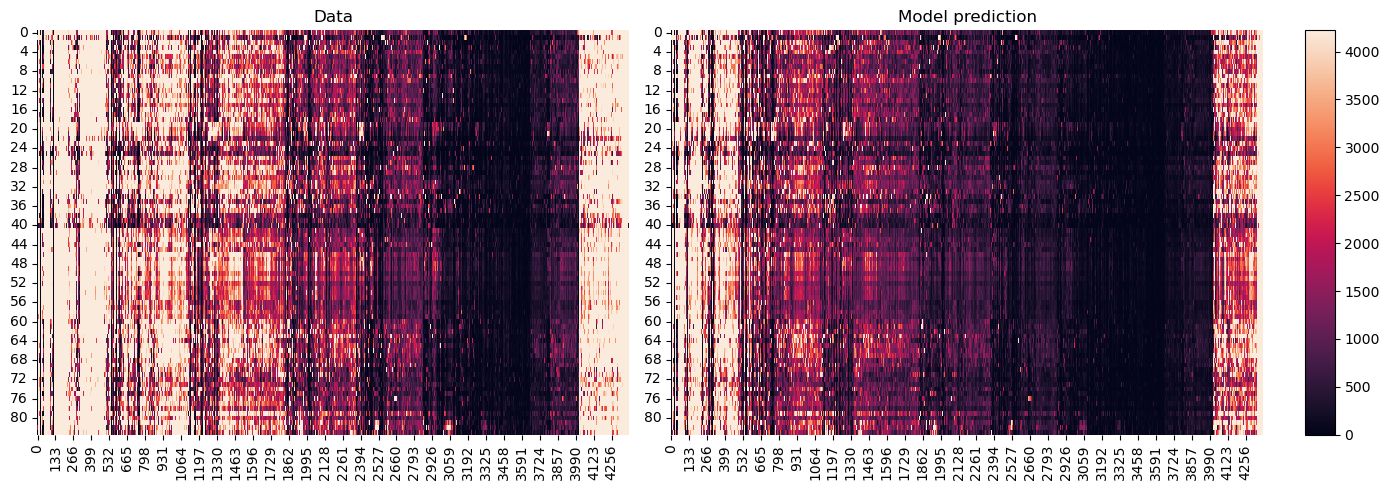

In [ ]:
# Cluster rows
row_linkage = sch.linkage(x_in, method='average')
row_dendro = sch.dendrogram(row_linkage, no_plot=True)
row_order = row_dendro['leaves']

# Cluster columns
col_linkage = sch.linkage(x_in.T, method='average')
col_dendro = sch.dendrogram(col_linkage, no_plot=True)
col_order = col_dendro['leaves']

# Reorder
x_in_ordered = x_in[np.ix_(row_order, col_order)]
x_out_ordered = x_out[np.ix_(row_order, col_order)]

# Set up a gridspec layout: 1 row, 3 columns
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])

# Create subplots according to gridspec
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# Common color scale
vmin = 0
vmax = np.percentile(x_in, 75)

# Plot heatmaps
sns.heatmap(x_in_ordered, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax0.set_title('Data')
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

sns.heatmap(x_out_ordered, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax1.set_title('Model prediction')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation='vertical')

plt.tight_layout()
plt.show()

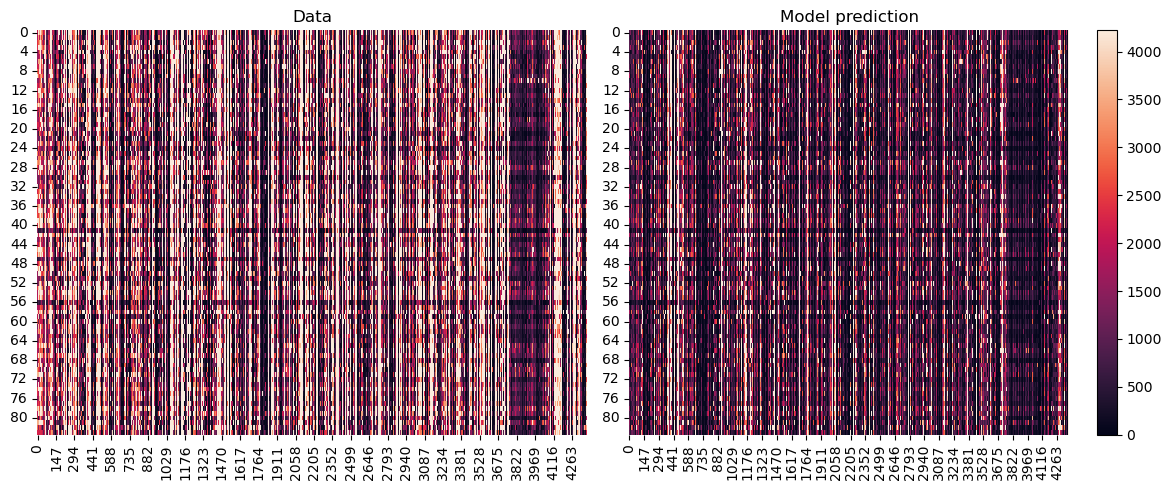

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.percentile(x_in, 75)

sns.heatmap(x_in, ax=axes[0], vmax=vmax, cbar=False)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].set_title('Data')

sns.heatmap(x_out, ax=axes[1], vmax=vmax, cbar=False)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[1].set_title('Model prediction')

norm = mpl.colors.Normalize(vmin=0, vmax=vmax)  # adjust vmin if needed
sm = mpl.cm.ScalarMappable(cmap='rocket', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], orientation='vertical',)


plt.tight_layout()
plt.show()

<Axes: >

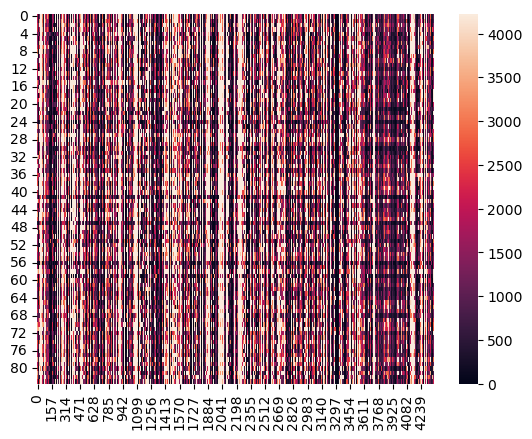

In [ ]:
sns.heatmap(x_in, vmax=np.percentile(x_in, 75))

<Axes: >

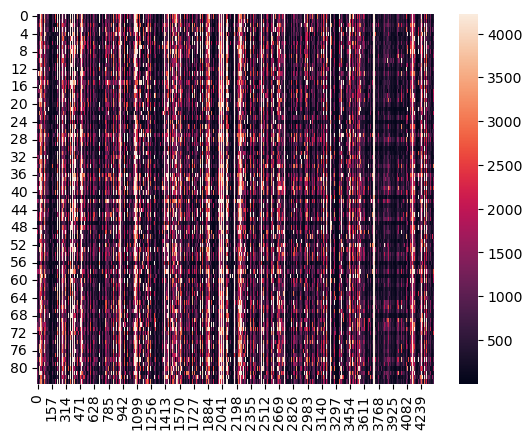

In [ ]:
sns.heatmap(x_out, vmax=np.percentile(x_in, 75))